In [1]:
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pdb
from IPython.display import display
import os
import glob

In [15]:
path = r'C:/Users/arj26323/Documents/Data/Tide data/GA_FortPulaski' 
all_files = glob.glob(path + "/*.csv")

li = []

for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    li.append(df)

df1 = pd.concat(li, axis=0, ignore_index=True)

df1['Time'] = df1['Time (GMT)']
df1['Tide_A'] = df1['Verified (m)']

df1

,Date,Time (GMT),Predicted (m),Preliminary (m),Verified (m),Time,Tide_A
0,1985/01/02,00:00,0.891,-,1.007,00:00,1.007
1,1985/01/02,01:00,0.540,-,0.681,01:00,0.681
2,1985/01/02,02:00,0.275,-,0.418,02:00,0.418
3,1985/01/02,03:00,0.187,-,0.354,03:00,0.354
4,1985/01/02,04:00,0.332,-,0.507,04:00,0.507
...,...,...,...,...,...,...,...
350635,1985/01/01,19:00,1.456,-,1.65,19:00,1.65
350636,1985/01/01,20:00,1.658,-,1.763,20:00,1.763
350637,1985/01/01,21:00,1.693,-,1.695,21:00,1.695
350638,1985/01/01,22:00,1.547,-,1.555,22:00,1.555


In [25]:
pathx = r'C:/Users/arj26323/Documents/Data/Tide data/FL_comparison' 
all_filesx = glob.glob(pathx + "/*.csv")

lix = []

for filename in all_filesx:
    dfx = pd.read_csv(filename, index_col=None, header=0)
    lix.append(dfx)

df2 = pd.concat(lix, axis=0, ignore_index=True)

df2['Time'] = df2['Time (GMT)']
df2['Tide_B'] = df2['Verified (m)']

df2['Date'].max()

'2023/12/31'

In [17]:
df1['Datetime'] = pd.to_datetime(df1['Date'] + ' ' + df1['Time'])
df2['Datetime'] = pd.to_datetime(df2['Date'] + ' ' + df2['Time'])

merged = pd.merge(df1[['Datetime', 'Tide_A']],
                  df2[['Datetime', 'Tide_B']],
                  on='Datetime',
                  how='inner')

In [30]:
merged['Tide_A'] = pd.to_numeric(merged['Tide_A'], errors='coerce')
merged['Tide_B'] = pd.to_numeric(merged['Tide_B'], errors='coerce')

merged = merged.dropna(subset=['Tide_A', 'Tide_B'])

print("Missing A:", merged['Tide_A'].isna().sum())
print("Missing B:", merged['Tide_B'].isna().sum())

print("Remaining:", len(merged))

merged

Missing A: 0
Missing B: 0
Remaining: 331598


,Datetime,Tide_A,Tide_B
0,1985-01-02 00:00:00,1.007,0.936
1,1985-01-02 01:00:00,0.681,0.631
2,1985-01-02 02:00:00,0.418,0.390
3,1985-01-02 03:00:00,0.354,0.268
4,1985-01-02 04:00:00,0.507,0.320
...,...,...,...
350611,1985-01-01 19:00:00,1.650,1.241
350612,1985-01-01 20:00:00,1.763,1.457
350613,1985-01-01 21:00:00,1.695,1.567
350614,1985-01-01 22:00:00,1.555,1.506


C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


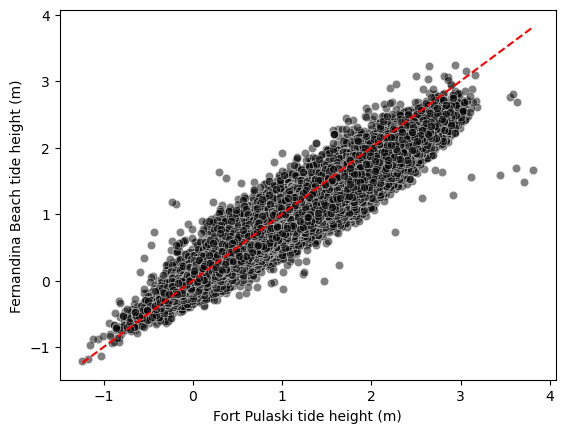

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=merged, x='Tide_A', y='Tide_B', alpha=0.5, color = 'black')
plt.plot([merged['Tide_A'].min(), merged['Tide_A'].max()],
         [merged['Tide_A'].min(), merged['Tide_A'].max()],
         color='red', linestyle='--')  # 1:1 reference line
plt.xlabel('Fort Pulaski tide height (m)')
plt.ylabel('Fernandina Beach tide height (m)')
# plt.title('Comparison of Tide Heights')

##Save at high res
import os
output_dir = r'F:\Loose figures'
file_name = 'tide_station_compare.tif'

save_path = os.path.join(output_dir, file_name)

# plt.savefig(save_path, bbox_inches='tight', dpi=1000)

plt.show()

In [34]:
from scipy.stats import pearsonr

r, p = pearsonr(merged['Tide_A'], merged['Tide_B'])
print(f"Pearson correlation = {r:.3f}, p = {p:.3e}")

Pearson correlation = 0.959, p = 0.000e+00


In [36]:
A_thresh = merged['Tide_A'].quantile(2/3)
B_thresh = merged['Tide_B'].quantile(2/3)
print(f"Upper tercile thresholds:\nA: {A_thresh:.2f}\nB: {B_thresh:.2f}")

Upper tercile thresholds:
A: 1.71
B: 1.46


In [37]:
merged['High_A'] = merged['Tide_A'] >= A_thresh
merged['High_B'] = merged['Tide_B'] >= B_thresh

In [40]:
# Count how many timestamps are high in both datasets
overlap = ((merged['High_A']) & (merged['High_B'])).sum()
total_high_A = merged['High_A'].sum()
total_high_B = merged['High_B'].sum()

In [44]:
print(f"High-tide overlap count: {overlap}")
print(f"Overlap relative to A: {overlap / total_high_A:.2%}")
print(f"Overlap relative to B: {overlap / total_high_B:.2%}")

High-tide overlap count: 93922
Overlap relative to A: 84.83%
Overlap relative to B: 84.92%


C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Catego

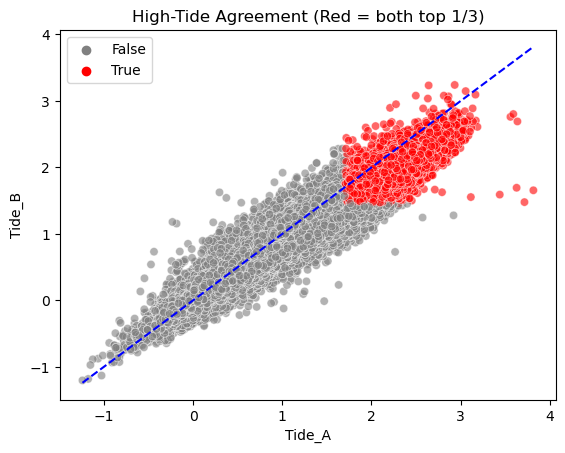

In [46]:
import seaborn as sns
sns.scatterplot(
    data=merged,
    x='Tide_A', y='Tide_B',
    hue=(merged['High_A'] & merged['High_B']),
    palette={True: 'red', False: 'gray'},
    alpha=0.6
)
plt.plot([merged['Tide_A'].min(), merged['Tide_A'].max()],
         [merged['Tide_A'].min(), merged['Tide_A'].max()],
         color='blue', linestyle='--')
plt.title('High-Tide Agreement (Red = both top 1/3)')
plt.show()

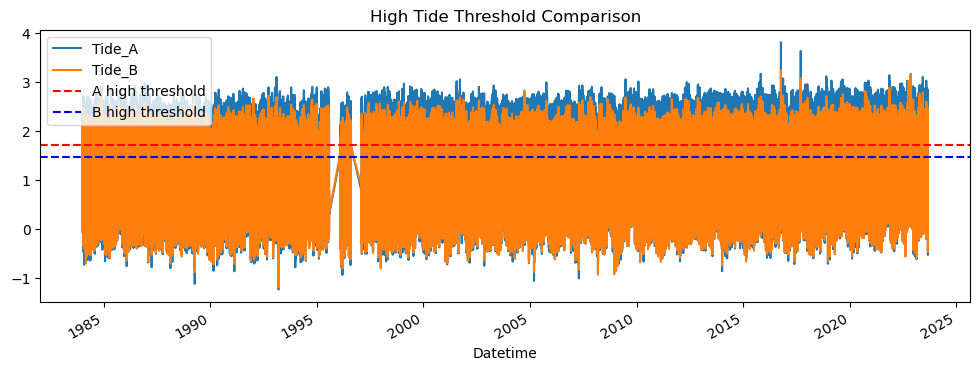

In [47]:
merged.set_index('Datetime')[['Tide_A','Tide_B']].plot(figsize=(12,4))
plt.axhline(A_thresh, color='red', linestyle='--', label='A high threshold')
plt.axhline(B_thresh, color='blue', linestyle='--', label='B high threshold')
plt.legend()
plt.title('High Tide Threshold Comparison')
plt.show()

In [48]:
# Jaccard index = intersection / union
jaccard = ((merged['High_A']) & (merged['High_B'])).sum() / \
          ((merged['High_A']) | (merged['High_B'])).sum()
print(f"Jaccard similarity of high-tide events: {jaccard:.2f}")

Jaccard similarity of high-tide events: 0.74


In [50]:
# Calculate tercile thresholds
A_low = merged['Tide_A'].quantile(1/3)
A_high = merged['Tide_A'].quantile(2/3)

B_low = merged['Tide_B'].quantile(1/3)
B_high = merged['Tide_B'].quantile(2/3)

# Identify high and low tides
High_A = merged['Tide_A'] >= A_high
High_B = merged['Tide_B'] >= B_high

Low_A = merged['Tide_A'] <= A_low
Low_B = merged['Tide_B'] <= B_low

# Jaccard: intersection / union
high_jaccard = (High_A & High_B).sum() / (High_A | High_B).sum()
low_jaccard = (Low_A & Low_B).sum() / (Low_A | Low_B).sum()

print(f"High-tide Jaccard: {high_jaccard:.3f}")
print(f"Low-tide Jaccard:  {low_jaccard:.3f}")

mean_jaccard = (high_jaccard + low_jaccard) / 2

print(f"Mean Jaccard: {mean_jaccard:.3f}")

High-tide Jaccard: 0.737
Low-tide Jaccard:  0.795
Mean Jaccard: 0.766
